# CLIP PEFT vs FFT Comparison

This notebook compares two CLIP training strategies for the aerial scene classification dataset.

- **PEFT**: frozen CLIP image encoder with a trainable classifier head.
- **FFT**: full fine-tuning of the CLIP vision encoder/projection plus classifier head.

Both runs use the same train-only augmentation and the same held-out validation split. Outputs are saved into separate report folders.

In [1]:
from pathlib import Path
import gc
import os
import random
import warnings

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
from tqdm import tqdm

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support

import matplotlib.pyplot as plt
import seaborn as sns

try:
    from transformers import CLIPModel, CLIPProcessor
except ImportError as exc:
    raise ImportError("Install transformers first: uv add transformers") from exc

os.environ["TOKENIZERS_PARALLELISM"] = "false"
warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", context="notebook")

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

TRAIN_DIR = PROJECT_ROOT / "data" / "raw" / "train"
VAL_DIR = PROJECT_ROOT / "data" / "raw" / "val"

MODEL_NAME = "openai/clip-vit-base-patch32"
NUM_WORKERS = 0

PEFT_BATCH_SIZE = 32
PEFT_EPOCHS = 10
PEFT_LR = 1e-3

FFT_BATCH_SIZE = 16
FFT_EPOCHS = 10
FFT_BACKBONE_LR = 1e-5
FFT_CLASSIFIER_LR = 1e-4

WEIGHT_DECAY = 1e-4

PEFT_OUTPUT_DIR = PROJECT_ROOT / "reports" / "clip_training" / "clip_peft_augmented"
FFT_OUTPUT_DIR = PROJECT_ROOT / "reports" / "clip_training" / "clip_fft_augmented"
COMPARISON_DIR = PROJECT_ROOT / "reports" / "clip_training" / "clip_peft_fft_comparison"
for directory in [PEFT_OUTPUT_DIR, FFT_OUTPUT_DIR, COMPARISON_DIR]:
    (directory / "figures").mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"

print(f"Project root: {PROJECT_ROOT.name}")
print(f"Train directory exists: {TRAIN_DIR.exists()} -> {TRAIN_DIR.resolve().relative_to(PROJECT_ROOT.resolve())}")
print(f"Validation directory exists: {VAL_DIR.exists()} -> {VAL_DIR.resolve().relative_to(PROJECT_ROOT.resolve())}")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version used by PyTorch: {torch.version.cuda}")

Project root: CSC3109_Project
Train directory exists: True -> data/raw/train
Validation directory exists: True -> data/raw/val
Device: cuda
GPU: NVIDIA GeForce RTX 4080 SUPER
CUDA version used by PyTorch: 13.0


## Dataset and Augmentation

In [3]:
class ImageFolderWithPaths(ImageFolder):
    def __getitem__(self, index):
        image, label = super().__getitem__(index)
        path = self.samples[index][0]
        return image, label, path


train_augmentation = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02),
])

train_dataset = ImageFolderWithPaths(TRAIN_DIR, transform=train_augmentation)
val_dataset = ImageFolderWithPaths(VAL_DIR)

class_names = train_dataset.classes
class_to_idx = train_dataset.class_to_idx
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}
num_classes = len(class_names)

assert class_names == val_dataset.classes, "Train and validation class folders do not match."
assert num_classes == 4, f"Expected 4 classes, found {num_classes}: {class_names}"

print("Classes:", class_names)
print(f"Training images: {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")

Classes: ['bridge', 'freeway', 'overpass', 'railway']
Training images: 2800
Validation images: 400


In [4]:
def class_counts(dataset, split_name):
    labels = [label for _, label in dataset.samples]
    counts = pd.Series(labels).map(idx_to_class).value_counts().reindex(class_names).fillna(0).astype(int)
    return pd.DataFrame({"split": split_name, "class": counts.index, "count": counts.values})


counts_df = pd.concat([
    class_counts(train_dataset, "train"),
    class_counts(val_dataset, "validation"),
], ignore_index=True)
display(counts_df)

,split,class,count
0,train,bridge,700
1,train,freeway,700
2,train,overpass,700
3,train,railway,700
4,validation,bridge,100
5,validation,freeway,100
6,validation,overpass,100
7,validation,railway,100


## Model and Training Helpers

In [5]:
processor = CLIPProcessor.from_pretrained(MODEL_NAME)


def collate_clip_batch(batch):
    images, labels, paths = zip(*batch)
    inputs = processor(images=list(images), return_tensors="pt")
    labels = torch.tensor(labels, dtype=torch.long)
    return inputs["pixel_values"], labels, list(paths)


def make_dataloaders(batch_size):
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
        collate_fn=collate_clip_batch,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        collate_fn=collate_clip_batch,
    )
    return train_loader, val_loader

In [6]:
class CLIPImageClassifier(nn.Module):
    def __init__(self, clip_model, embedding_dim, num_classes, fine_tune=False):
        super().__init__()
        self.clip_model = clip_model
        self.fine_tune = fine_tune
        self.classifier = nn.Linear(embedding_dim, num_classes)

        for parameter in self.clip_model.parameters():
            parameter.requires_grad = False

        if fine_tune:
            for parameter in self.clip_model.vision_model.parameters():
                parameter.requires_grad = True
            for parameter in self.clip_model.visual_projection.parameters():
                parameter.requires_grad = True

    def extract_image_features(self, pixel_values):
        if self.fine_tune:
            vision_outputs = self.clip_model.vision_model(pixel_values=pixel_values)
            image_features = self.clip_model.visual_projection(vision_outputs.pooler_output)
        else:
            with torch.no_grad():
                vision_outputs = self.clip_model.vision_model(pixel_values=pixel_values)
                image_features = self.clip_model.visual_projection(vision_outputs.pooler_output)
        return F.normalize(image_features, dim=-1)

    def forward(self, pixel_values):
        return self.classifier(self.extract_image_features(pixel_values))


def build_model(fine_tune):
    clip_model = CLIPModel.from_pretrained(MODEL_NAME).to(DEVICE)
    model = CLIPImageClassifier(
        clip_model=clip_model,
        embedding_dim=clip_model.config.projection_dim,
        num_classes=num_classes,
        fine_tune=fine_tune,
    ).to(DEVICE)
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Frozen parameters: {frozen_params:,}")
    return model

In [7]:
def make_optimizer(model, fine_tune):
    if fine_tune:
        return torch.optim.AdamW(
            [
                {"params": model.classifier.parameters(), "lr": FFT_CLASSIFIER_LR},
                {"params": model.clip_model.vision_model.parameters(), "lr": FFT_BACKBONE_LR},
                {"params": model.clip_model.visual_projection.parameters(), "lr": FFT_BACKBONE_LR},
            ],
            weight_decay=WEIGHT_DECAY,
        )

    return torch.optim.AdamW(model.classifier.parameters(), lr=PEFT_LR, weight_decay=WEIGHT_DECAY)


def run_epoch(model, dataloader, criterion, optimizer=None, scaler=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()
    if not model.fine_tune:
        model.clip_model.eval()

    total_loss = 0.0
    all_targets = []
    all_predictions = []

    for pixel_values, labels, _ in tqdm(dataloader, leave=False):
        pixel_values = pixel_values.to(DEVICE)
        labels = labels.to(DEVICE)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            with torch.amp.autocast(device_type=DEVICE.type, enabled=USE_AMP):
                logits = model(pixel_values)
                loss = criterion(logits, labels)

        if is_training:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        total_loss += loss.item() * labels.size(0)
        predictions = logits.argmax(dim=1)
        all_targets.extend(labels.detach().cpu().numpy())
        all_predictions.extend(predictions.detach().cpu().numpy())

    return total_loss / len(dataloader.dataset), accuracy_score(all_targets, all_predictions)

In [8]:
@torch.no_grad()
def predict_dataset(model, dataloader):
    model.eval()
    records = []

    for pixel_values, labels, paths in tqdm(dataloader, desc="Predicting validation set"):
        pixel_values = pixel_values.to(DEVICE)
        labels = labels.to(DEVICE)
        logits = model(pixel_values)
        probabilities = logits.softmax(dim=1)
        predictions = probabilities.argmax(dim=1)
        confidence_scores = probabilities.max(dim=1).values

        for path, true_idx, pred_idx, confidence in zip(paths, labels.cpu().numpy(), predictions.cpu().numpy(), confidence_scores.cpu().numpy()):
            records.append({
                "path": path,
                "true_idx": int(true_idx),
                "pred_idx": int(pred_idx),
                "true_label": idx_to_class[int(true_idx)],
                "pred_label": idx_to_class[int(pred_idx)],
                "confidence": float(confidence),
                "correct": int(true_idx) == int(pred_idx),
            })

    return pd.DataFrame(records)


def summarize_predictions(results_df):
    y_true = results_df["true_label"]
    y_pred = results_df["pred_label"]
    accuracy = accuracy_score(y_true, y_pred)
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    return pd.DataFrame([
        {"metric": "accuracy", "value": accuracy},
        {"metric": "macro_precision", "value": macro_precision},
        {"metric": "macro_recall", "value": macro_recall},
        {"metric": "macro_f1", "value": macro_f1},
        {"metric": "weighted_precision", "value": weighted_precision},
        {"metric": "weighted_recall", "value": weighted_recall},
        {"metric": "weighted_f1", "value": weighted_f1},
    ])

In [9]:
def save_run_outputs(run_name, output_dir, model, history_df, results_df, summary_metrics, save_full_model):
    figure_dir = output_dir / "figures"
    report_df = pd.DataFrame(
        classification_report(results_df["true_label"], results_df["pred_label"], labels=class_names, output_dict=True, zero_division=0)
    ).transpose()

    results_df.to_csv(output_dir / "predictions.csv", index=False)
    history_df.to_csv(output_dir / "history.csv", index=False)
    summary_metrics.to_csv(output_dir / "summary_metrics.csv", index=False)
    report_df.to_csv(output_dir / "classification_report.csv")
    torch.save(model.classifier.state_dict(), output_dir / "classifier_head.pt")
    if save_full_model:
        torch.save(model.state_dict(), output_dir / "model_state.pt")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation")
    axes[0].set_title(f"{run_name} Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-Entropy Loss")
    axes[0].legend()
    axes[1].plot(history_df["epoch"], history_df["train_accuracy"], marker="o", label="Train")
    axes[1].plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="Validation")
    axes[1].set_title(f"{run_name} Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(figure_dir / "training_curves.png", dpi=300, bbox_inches="tight")
    plt.show()

    cm = confusion_matrix(results_df["true_label"], results_df["pred_label"], labels=class_names)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{run_name} Confusion Matrix")
    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.tight_layout()
    plt.savefig(figure_dir / "confusion_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved {run_name} outputs to: {output_dir.resolve().relative_to(PROJECT_ROOT.resolve())}")
    return report_df

In [10]:
def run_experiment(run_name, fine_tune, batch_size, epochs, output_dir):
    print(f"\n=== {run_name} ===")
    train_loader, val_loader = make_dataloaders(batch_size)
    model = build_model(fine_tune=fine_tune)
    criterion = nn.CrossEntropyLoss()
    optimizer = make_optimizer(model, fine_tune=fine_tune)
    scaler = torch.amp.GradScaler(device=DEVICE.type, enabled=USE_AMP)
    history = []

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer=optimizer, scaler=scaler)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None, scaler=scaler)
        history.append({"epoch": epoch, "train_loss": train_loss, "train_accuracy": train_acc, "val_loss": val_loss, "val_accuracy": val_acc})
        print(f"Epoch {epoch:02d}/{epochs} | train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

    history_df = pd.DataFrame(history)
    results_df = predict_dataset(model, val_loader)
    summary_metrics = summarize_predictions(results_df)
    report_df = save_run_outputs(run_name, output_dir, model, history_df, results_df, summary_metrics, save_full_model=fine_tune)
    display(summary_metrics)

    return {"run_name": run_name, "model": model, "history": history_df, "results": results_df, "summary": summary_metrics, "report": report_df, "output_dir": output_dir}

## Run PEFT


=== CLIP PEFT Augmented ===


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Trainable parameters: 2,052
Frozen parameters: 151,277,313


  0%| | 0/88 [

  1%| | 1/88 [

...

Predicting vali

Predicting vali

Predicting vali

Predicting vali

Predicting vali

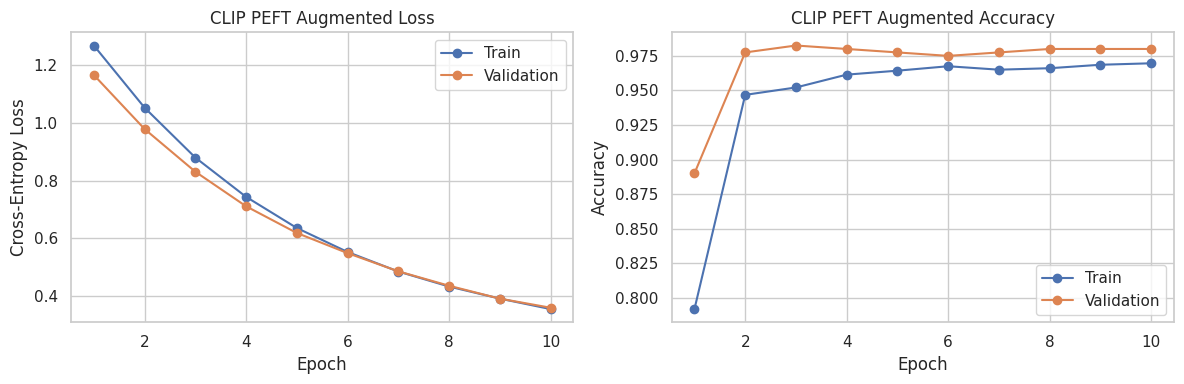

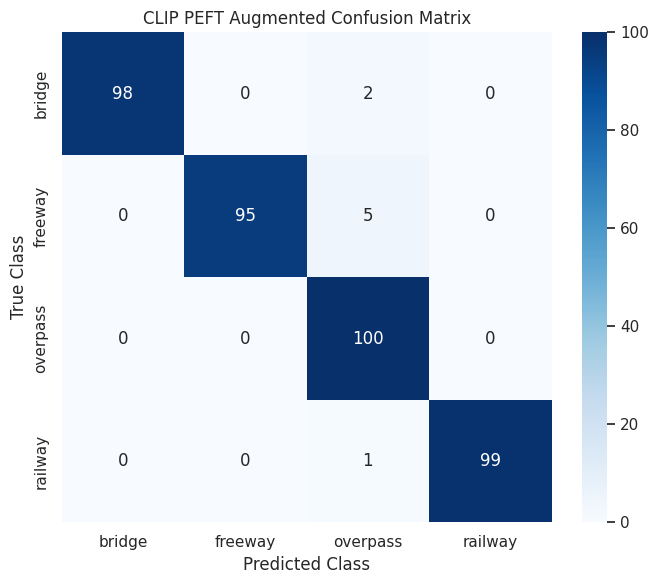

Saved CLIP PEFT Augmented outputs to: reports/clip_training/clip_peft_augmented


,metric,value
0,accuracy,0.980000
1,macro_precision,0.981481
2,macro_recall,0.980000
3,macro_f1,0.980193
4,weighted_precision,0.981481
5,weighted_recall,0.980000
6,weighted_f1,0.980193


In [11]:
peft_run = run_experiment(
    run_name="CLIP PEFT Augmented",
    fine_tune=False,
    batch_size=PEFT_BATCH_SIZE,
    epochs=PEFT_EPOCHS,
    output_dir=PEFT_OUTPUT_DIR,
)

In [12]:
del peft_run["model"]
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

## Run FFT


=== CLIP FFT Augmented ===


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Trainable parameters: 87,851,268
Frozen parameters: 63,428,097


  0%| | 0/175 [

  1%| | 1/175 [

...

Predicting vali

Predicting vali

Predicting vali

Predicting vali

Predicting vali

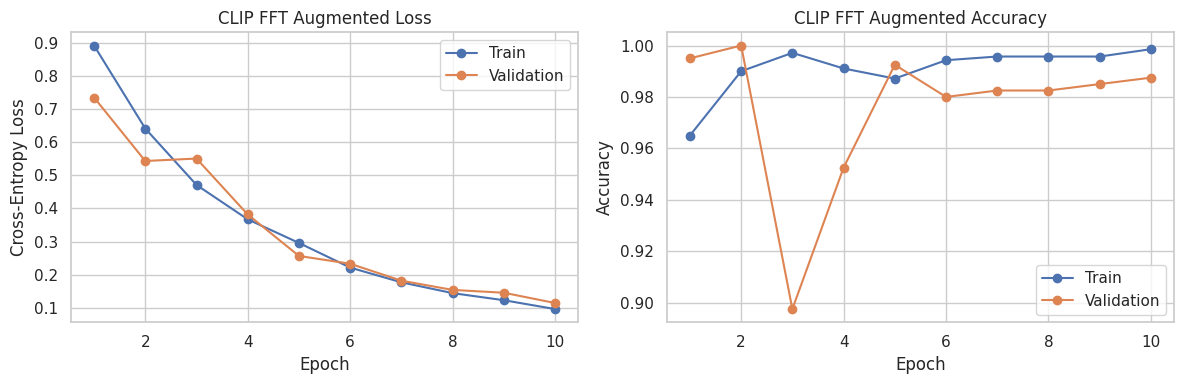

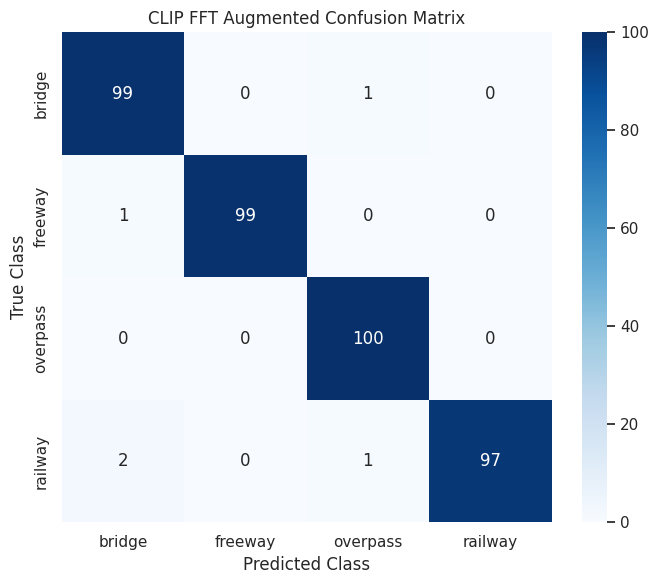

Saved CLIP FFT Augmented outputs to: reports/clip_training/clip_fft_augmented


,metric,value
0,accuracy,0.987500
1,macro_precision,0.987745
2,macro_recall,0.987500
3,macro_f1,0.987511
4,weighted_precision,0.987745
5,weighted_recall,0.987500
6,weighted_f1,0.987511


In [13]:
fft_run = run_experiment(
    run_name="CLIP FFT Augmented",
    fine_tune=True,
    batch_size=FFT_BATCH_SIZE,
    epochs=FFT_EPOCHS,
    output_dir=FFT_OUTPUT_DIR,
)

## Compare PEFT and FFT

,run,output_dir,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,CLIP PEFT Augmented,/home/william/school_projects/CSC3109_Project/...,0.9800,0.981481,0.9800,0.980193,0.981481,0.9800,0.980193
1,CLIP FFT Augmented,/home/william/school_projects/CSC3109_Project/...,0.9875,0.987745,0.9875,0.987511,0.987745,0.9875,0.987511


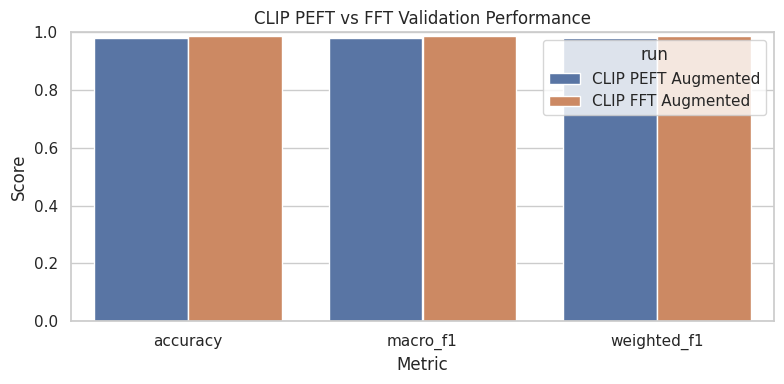

Saved comparison outputs to: reports/clip_training/clip_peft_fft_comparison


In [14]:
def summary_to_row(run):
    row = {"run": run["run_name"], "output_dir": str(run["output_dir"])}
    row.update(dict(zip(run["summary"]["metric"], run["summary"]["value"])))
    return row


comparison_df = pd.DataFrame([summary_to_row(peft_run), summary_to_row(fft_run)])
comparison_df.to_csv(COMPARISON_DIR / "comparison_summary.csv", index=False)
display(comparison_df)

plot_df = comparison_df.melt(id_vars="run", value_vars=["accuracy", "macro_f1", "weighted_f1"], var_name="metric", value_name="score")
plt.figure(figsize=(8, 4))
sns.barplot(data=plot_df, x="metric", y="score", hue="run")
plt.ylim(0, 1.0)
plt.title("CLIP PEFT vs FFT Validation Performance")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.tight_layout()
plt.savefig(COMPARISON_DIR / "figures" / "peft_vs_fft_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved comparison outputs to: {COMPARISON_DIR.resolve().relative_to(PROJECT_ROOT.resolve())}")